In [1]:
import requests
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OPENWEATHER_API_KEY")

print("API key loaded:", API_KEY is not None)


API key loaded: True


In [ ]:
city = "Lagos"

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params=params)

print(response.status_code)

weather_data = response.json()

weather_data


200


In [20]:
cities = ["Lagos", "Abuja", "Port Harcourt", "Kano", "Enugu"]

weather_data = []

for city in cities:
    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()

        weather_data.append({
            "city": data["name"],
            "temperature": data["main"]["temp"],
            "humidity": data["main"]["humidity"],
            "weather_condition": data["weather"][0]["description"],
            "wind_speed": data["wind"]["speed"],
            "date_time": pd.to_datetime(data["dt"], unit="s")
        })

    else:
        print(f"Could not retrieve data for {city}")

weather_df = pd.DataFrame(weather_data)

weather_df

,city,temperature,humidity,weather_condition,wind_speed,date_time
0,Lagos,28.91,70,broken clouds,3.39,2026-08-22 09:40:56
1,Abuja,27.17,75,scattered clouds,1.78,2026-08-22 09:50:18
2,Port Harcourt,26.92,78,light rain,3.27,2026-08-22 09:51:30
3,Kano,31.74,48,scattered clouds,4.03,2026-08-22 09:51:15
4,Enugu,26.87,82,overcast clouds,2.66,2026-08-22 09:51:34


In [32]:
import os

os.makedirs("data", exist_ok=True)

weather_df.to_csv("data/raw_weather_data.csv", index=False)

print("Raw weather data saved successfully.")

Raw weather data saved successfully.


In [43]:
weather_df.info()
weather_df.isnull().sum()
weather_df.duplicated().sum()
weather_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   city               5 non-null      str          
 1   temperature        5 non-null      float64      
 2   humidity           5 non-null      int64        
 3   weather_condition  5 non-null      str          
 4   wind_speed         5 non-null      float64      
 5   date_time          5 non-null      datetime64[s]
dtypes: datetime64[s](1), float64(2), int64(1), str(2)
memory usage: 372.0 bytes


,temperature,humidity,wind_speed,date_time
count,5.000000,5.000000,5.000000,5
mean,28.322000,70.600000,3.026000,2026-08-22 09:49:06
min,26.870000,48.000000,1.780000,2026-08-22 09:40:56
25%,26.920000,70.000000,2.660000,2026-08-22 09:50:18
50%,27.170000,75.000000,3.270000,2026-08-22 09:51:15
75%,28.910000,78.000000,3.390000,2026-08-22 09:51:30
max,31.740000,82.000000,4.030000,2026-08-22 09:51:34
std,2.087431,13.371612,0.849488,NaN


In [53]:
weather_df.to_csv("data/cleaned_weather_data.csv", index=False)

print("Cleaned weather data saved successfully.")

Cleaned weather data saved successfully.


In [62]:
import os

os.path.exists("data/cleaned_weather_data.csv")

True

In [63]:
#City with the highest average temperature
weather_df.groupby("city")["temperature"].mean().sort_values(ascending=False)

city
Kano             31.74
Lagos            28.91
Abuja            27.17
Port Harcourt    26.92
Enugu            26.87
Name: temperature, dtype: float64

In [64]:
#City with the highest humidity
weather_df.loc[weather_df["humidity"].idxmax(), ["city", "humidity"]]

city        Enugu
humidity       82
Name: 4, dtype: object

In [65]:
#city with the highest temperature
weather_df.loc[weather_df["temperature"].idxmax(), ["city", "temperature"]]

city            Kano
temperature    31.74
Name: 3, dtype: object

In [66]:
#city with the lowest temperature
weather_df.loc[weather_df["temperature"].idxmin(), ["city", "temperature"]]

city           Enugu
temperature    26.87
Name: 4, dtype: object

In [67]:
#city with the highest wind speed
weather_df.loc[weather_df["wind_speed"].idxmax(), ["city", "wind_speed"]]

city          Kano
wind_speed    4.03
Name: 3, dtype: object

In [68]:
#weather condition counts
weather_df["weather_condition"].value_counts()

weather_condition
scattered clouds    2
broken clouds       1
light rain          1
overcast clouds     1
Name: count, dtype: int64

In [69]:
#summary of the weather data
summary = weather_df[
    ["city", "temperature", "humidity", "weather_condition", "wind_speed"]
].sort_values("temperature", ascending=False)

summary

,city,temperature,humidity,weather_condition,wind_speed
3,Kano,31.74,48,scattered clouds,4.03
0,Lagos,28.91,70,broken clouds,3.39
1,Abuja,27.17,75,scattered clouds,1.78
2,Port Harcourt,26.92,78,light rain,3.27
4,Enugu,26.87,82,overcast clouds,2.66


In [70]:
average_temperature = weather_df["temperature"].mean()

print(f"Average temperature: {average_temperature:.2f}°C")

Average temperature: 28.32°C


In [71]:
average_humidity = weather_df["humidity"].mean()

print(f"Average humidity: {average_humidity:.2f}%")


Average humidity: 70.60%


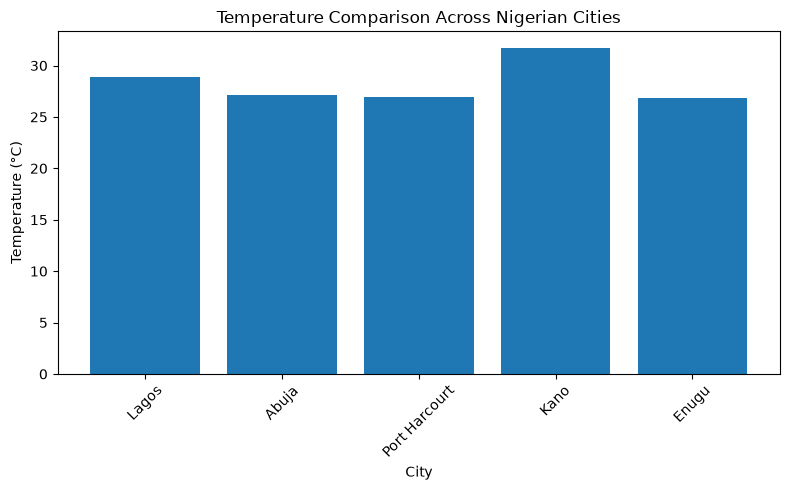

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(weather_df["city"], weather_df["temperature"])

plt.title("Temperature Comparison Across Nigerian Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

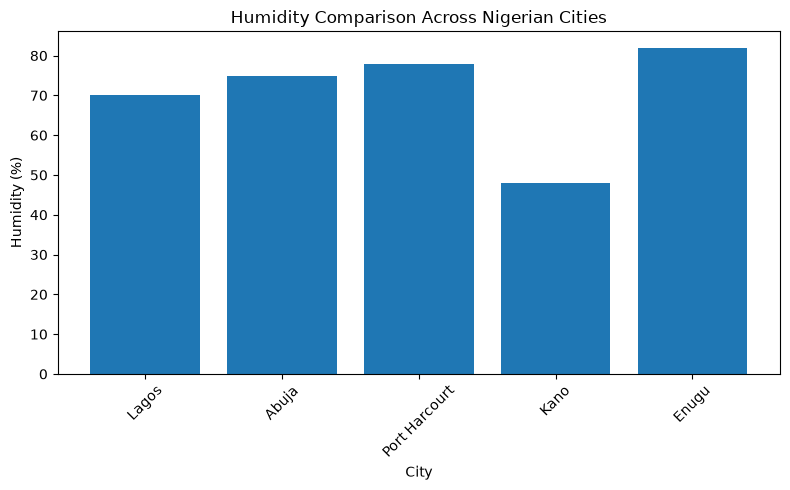

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(weather_df["city"], weather_df["humidity"])

plt.title("Humidity Comparison Across Nigerian Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [74]:
highest_temp = weather_df.loc[weather_df["temperature"].idxmax()]
lowest_temp = weather_df.loc[weather_df["temperature"].idxmin()]
highest_humidity = weather_df.loc[weather_df["humidity"].idxmax()]
highest_wind = weather_df.loc[weather_df["wind_speed"].idxmax()]

print(f"Average temperature: {weather_df['temperature'].mean():.2f}°C")
print(f"Average humidity: {weather_df['humidity'].mean():.2f}%")
print(f"Hottest city: {highest_temp['city']} ({highest_temp['temperature']:.2f}°C)")
print(f"Coolest city: {lowest_temp['city']} ({lowest_temp['temperature']:.2f}°C)")
print(f"Highest humidity: {highest_humidity['city']} ({highest_humidity['humidity']}%)")
print(f"Highest wind speed: {highest_wind['city']} ({highest_wind['wind_speed']:.2f} m/s)")

Average temperature: 28.32°C
Average humidity: 70.60%
Hottest city: Kano (31.74°C)
Coolest city: Enugu (26.87°C)
Highest humidity: Enugu (82%)
Highest wind speed: Kano (4.03 m/s)
